In [337]:
# based on the following tutorial
# https://www.deeplearningwizard.com/deep_learning/practical_pytorch/pytorch_linear_regression/

# Playground Linear Regression w Basis Expansion

* based on Sample Dataset consisting of n samples with (x,y)
* Implement linear regression based on
    * least-squares
    * linear layer
    * mlp
    * transformer
* Same for cubic regression
* Comparison and Summary

## Imports

In [14]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# import torch
import torch
import torch.nn as nn


## Dataset

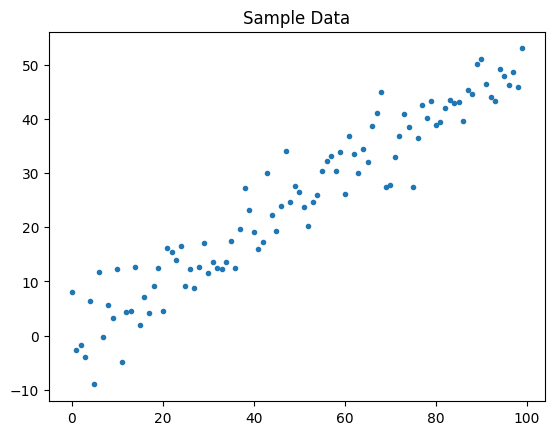

In [29]:
np.random.seed(1)
n = 100

x = np.arange(0, n)
y = np.random.randn(n) * 5 + 0.5 * x

# plot points
plt.plot(x, y, '.')
plt.title('Sample Data')
plt.show()

## PreProcessing

In [31]:
# convert list to 2D numpy array
x_train = np.array(x, dtype=np.float32).reshape(-1, 1)
print(x_train.shape)
y_train = np.array(y, dtype=np.float32).reshape(-1, 1)
print(y_train.shape)

(100, 1)
(100, 1)


## Least-Squares Solution

* assume linear model: y = ax + b
* Define Design Matrix A
* Minimize squared errors

### Theorie: Least-Squares und die Design Matrix

**Funktionales Modell** (linear in den Parametern):

$$y_i = a \cdot x_i + b$$

mit den **Unbekannten** $\theta = [a, b]^\top$.

---

**Design Matrix / Jacobi-Matrix**

Ableitung von $y_i$ nach den Unbekannten:

$$\frac{\partial y_i}{\partial a} = x_i, \qquad \frac{\partial y_i}{\partial b} = 1$$

Für alle $n$ Beobachtungen ergibt sich die Design Matrix $A$ (= Jacobi-Matrix $J$):

$$A = J = \begin{bmatrix} x_0 & 1 \\ x_1 & 1 \\ \vdots & \vdots \\ x_{n-1} & 1 \end{bmatrix} \in \mathbb{R}^{n \times 2}$$

Da das Modell **linear** in $\theta$ ist, sind die Einträge konstant – $A$ hängt nicht von den Parametern ab.

> Bei nichtlinearen Modellen hängt $J$ von den aktuellen Parameterwerten ab → iterative Lösung nötig (z.B. Gauss-Newton).

---

**Least-Squares Lösung**

Das überbestimmte Gleichungssystem ($n$ Gleichungen, 2 Unbekannte):

$$A \cdot \theta \approx y$$

wird durch Minimierung der quadratischen Summe der Residuen gelöst:

$$\min_\theta \| A\theta - y \|^2$$

Normalgleichung und geschlossene Lösung (Pseudoinverse):

$$\theta^* = (A^\top A)^{-1} A^\top y$$


In [35]:
# Design Matrix
A = np.hstack([np.ones_like(x_train), x_train])
# Lösung der Normalengleichung
theta = np.linalg.inv(A.T @ A) @ A.T @ y_train
print(theta)

[[-0.52419513]
 [ 0.51670927]]


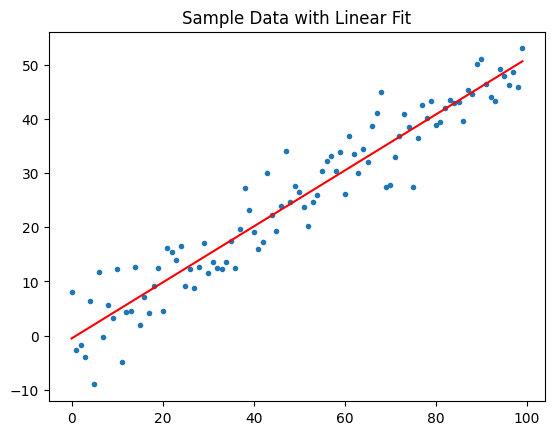

In [36]:
# plotte die Gerade mit den Parameters a und b zusammen mit den Datenpunkten
a, b = theta[1][0], theta[0][0]
plt.plot(x, y, '.')
plt.plot(x, a * x + b, 'r-')
plt.title('Sample Data with Linear Fit')
plt.show() 


# Using Linear Layer

In [77]:
# now, build the model
# Create class
class LinearRegressionModel1(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel1, self).__init__()
        self.linear1 = nn.Linear(input_dim, output_dim, bias=True)

    def forward(self, x):
        out = self.linear1(x)
        return out

model = LinearRegressionModel1(input_dim=1, output_dim=1)
# anzahl der parameter in model
print(sum(p.numel() for p in model.parameters()))

2


In [78]:
# loss
criterion = nn.MSELoss()
# optimizer
learning_rate = 0.001
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

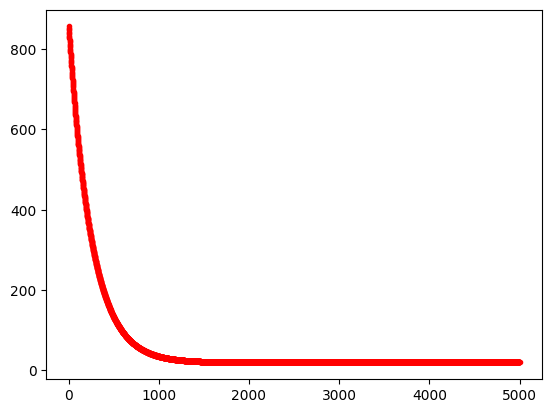

In [ ]:
# normiere inputs x
x_train_norm = (x_train - x_train.mean()) / x_train.std()
inputs = torch.from_numpy(x_train_norm)
labels = torch.from_numpy(y_train)

# train the model
epochs = 5000
for epoch in range(epochs):
    epoch += 1

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    #print(f'epoch {epoch}, loss {loss.item()}')
    plt.plot(epoch, loss.item(), 'r.')
    
# print loss
#plt.ylim(15, 25)
plt.show()

In [83]:
# inspect the learned parameters
[w, b] = model.parameters()
print(f'weight: {w[0][0].item()}, bias: {b[0].item()}')

weight: 14.914721488952637, bias: 25.051719665527344


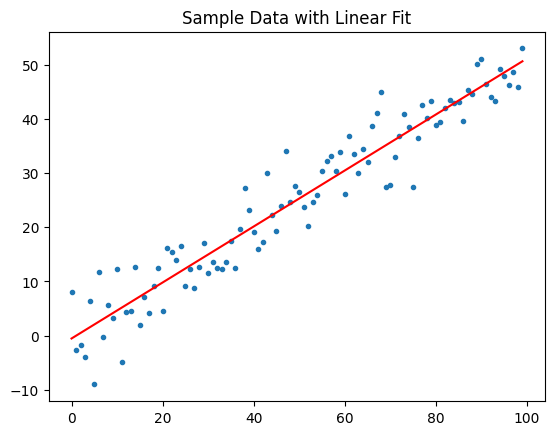

In [84]:
# plotte die gerade mit den gelernten Paramtern für a und b (aka weight und bias) zusammen mit den Datenpunkten
a, b = w[0][0].item(), b[0].item()
plt.plot(x, y, '.')
plt.plot(x, a * x_train_norm + b, 'r-')
plt.title('Sample Data with Linear Fit')
plt.show()

MSE Loss:

$$L = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

Substitution $u = \hat{y}_i - y_i$, dann ist $L \propto u^2$

Kettenregel:

$$\frac{\partial L}{\partial a} = \frac{1}{n} \sum_{i=1}^{n} \frac{\partial}{\partial a}(\hat{y}i - y_i)^2 = \frac{1}{n} \sum{i=1}^{n} \underbrace{2(\hat{y}i - y_i)}{\text{äußere Abl.}} \cdot \underbrace{\frac{\partial \hat{y}i}{\partial a}}{\text{innere Abl.}}$$

Innere Ableitung (= Jacobi-Spalte!):

$$\frac{\partial \hat{y}_i}{\partial a} = \frac{\partial}{\partial a}(a \cdot x_i + b) = x_i$$

Fertiger Gradient:

$$\boxed{\frac{\partial L}{\partial a} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) \cdot x_i}$$

-------------------------------------------------------------------------------------------------------------------------------------------------------

 Tipp: Mit $L = \frac{1}{2n}\sum(...)^2$ kürzt sich die 2 raus — viele Lehrbücher schreiben es so, damit die Formel sauberer aussieht. Das Minimum ändert sich dadurch nicht.

## Using MLP

In [106]:
# now, build the model
# Create class
class LinearRegressionModelMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModelMLP, self).__init__()
        embedding_dim = 512
        self.linear1 = nn.Linear(input_dim, embedding_dim)
        self.linear2 = nn.ReLU()
        self.linear3 = nn.Linear(embedding_dim, embedding_dim)
        self.linear4 = nn.ReLU()
        self.linear5 = nn.Linear(embedding_dim, output_dim)

    def forward(self, x):
        x = self.linear1(x)
        x = self.linear2(x)
        x = self.linear3(x)
        x = self.linear4(x)
        x = self.linear5(x)
        
        return x

model = LinearRegressionModelMLP(input_dim=1, output_dim=1)
# anzahl der parameter in model
print(sum(p.numel() for p in model.parameters()))

264193


In [107]:
# loss
criterion = nn.MSELoss()
# optimizer
learning_rate = 0.0001
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

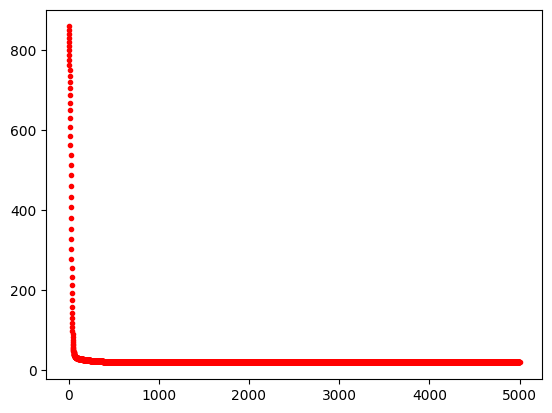

In [ ]:
# normiere inputs x
x_train_norm = (x_train - x_train.mean()) / x_train.std()
inputs = torch.from_numpy(x_train_norm)
labels = torch.from_numpy(y_train)

# train the model
epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad() # reset gradients
    outputs = model(inputs) # forward pass
    loss = criterion(outputs, labels) # compute loss
    loss.backward() # backward pass
    optimizer.step() # update parameters
    #print(f'epoch {epoch}, loss {loss.item()}')
    plt.plot(epoch, loss.item(), 'r.')
    
# print loss
#plt.ylim(15, 25)
plt.show()

In [100]:
# inspect the learned parameters
w = model.parameters()
# print per layer
print(list(model.parameters()))

[Parameter containing:
tensor([[ 0.1329],
        [-0.3671],
        [ 1.0611],
        [-0.0045],
        [-0.5053],
        [ 0.7912],
        [ 0.2975],
        [-0.6228],
        [-0.6884],
        [ 0.4272],
        [ 0.6237],
        [ 0.9294],
        [ 0.7320],
        [-0.3534],
        [-0.6765],
        [ 0.0064],
        [-0.4966],
        [ 0.5600],
        [ 0.5502],
        [-0.1389],
        [ 0.6958],
        [-0.7329],
        [-0.7865],
        [ 0.1147],
        [ 0.9715],
        [-0.1367],
        [-0.3479],
        [-0.8879],
        [-0.9307],
        [-0.6239],
        [-0.7074],
        [-0.9104],
        [-0.4286],
        [-1.0336],
        [ 0.7068],
        [ 1.1959],
        [ 0.2517],
        [ 0.6986],
        [ 0.4144],
        [ 0.6950],
        [-0.8923],
        [-0.5110],
        [ 0.1001],
        [-0.9678],
        [-0.0341],
        [ 0.4012],
        [ 0.6929],
        [ 0.9428],
        [ 0.2012],
        [ 0.8879]], requires_grad=True), Param

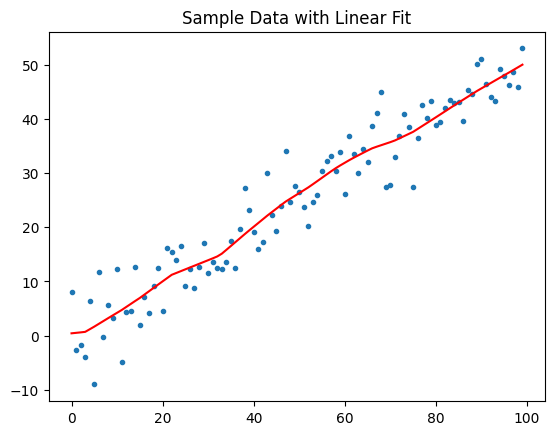

In [105]:
# plotte the fitted line together with the data points
predicted = model(inputs).detach().numpy()
plt.plot(x, y, '.')
plt.plot(x, predicted, 'r-')
plt.title('Sample Data with Linear Fit')
plt.show()